Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [1]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [2]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

FD_df = pd.DataFrame(training_data_FD)
kbg_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([FD_df,kbg_df])

inv_mass = full_data["inv_mass"].values


In [4]:
print(len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))

#ratio background signal

810.3201663201663


In [5]:


#leave out inv_mass and pt
features = [c for c in full_data.columns 
            if c not in ["inv_mass", "pt_cand", "species"]]

x_data = full_data[features]
y_data = full_data['species']
print(set(y_data))

# stratify to ensure: fraction signal / background in train is approx. fraction signal / background in test
# if for example x_test[10] is selected, then : y_test[10] the label, and m_test[10] the invariant mass of event
x_train_full, x_test, y_train_full, y_test, m_train, m_test = train_test_split(
    x_data,
    y_data,
    inv_mass,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)


print(np.unique(y_train_full, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.

pos_class_weight = (len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))




{0.0, 1.0}
(array([0., 1.]), array([3741734,    4618]))


In [6]:
train_x, val_x, train_y, val_y, m_train, m_val = train_test_split(x_train_full, y_train_full, m_train, test_size=0.2, random_state=42, stratify=y_train_full)
dtrain = xgb.DMatrix(train_x, label=train_y)
dval = xgb.DMatrix(val_x, label=val_y)




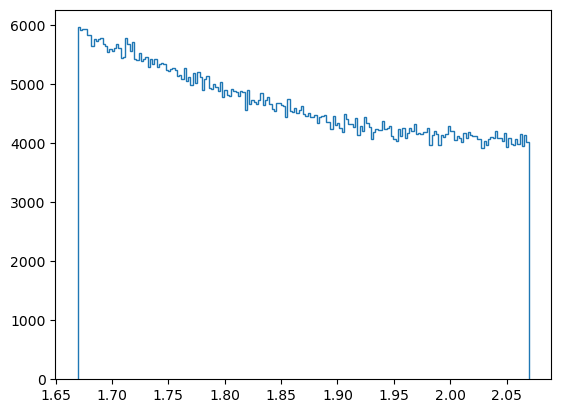

In [7]:
plt.hist(m_test[y_test==0], bins=200, histtype="step", label="Bkg (no cut)")
plt.show()

In [8]:
import optuna
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import average_precision_score


from optuna.integration import XGBoostPruningCallback
import xgboost as xgb

# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.

#In HEP: fixed validation set is crucial, so: splitting data outside the loop.



def objective(trial):

   
    params = {
        "verbosity": 0,
       
        'n_estimators': trial.suggest_int('n_estimators', 1500, 3000),

        'min_child_weight': trial.suggest_int('min_child_weight', 15, 45),
        # scale_pos_weight tune (not reccomended):
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", (pos_class_weight*0.9), (pos_class_weight*1.1))
        

        "scale_pos_weight": pos_class_weight,  # fixed class weight
        "reg_alpha": trial.suggest_float("reg_alpha", 5.0, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 50.0, 150.0, log=True),
    
       # "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "gamma": trial.suggest_float("gamma", 0.01, 1.0, log=True),

        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True), #09
        "max_depth": trial.suggest_int("max_depth", 2, 6), 
        "subsample": trial.suggest_float("subsample", 0.3, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 0.9),
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "max_delta_step": 1,
        "random_state": 42
    }
    num_boost_round = 1000 
    #params.update(base_params)
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-aucpr")
    bst = xgb.train(params, dtrain=dtrain, early_stopping_rounds=30, num_boost_round=num_boost_round, evals=[(dval, "validation")], callbacks=[pruning_callback])
    trial.set_user_attr('best_iteration', bst.best_iteration)

    scores = bst.predict(dval)

    
    y_true = val_y

    auc_val = average_precision_score(y_true, scores)


    trial.set_user_attr("val_aucpr", auc_val)


    return auc_val




if __name__ == "__main__":
    study = optuna.create_study(
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=15), direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=60)
    print("Best trial:")
    print(study.best_trial)



[I 2026-01-21 17:56:38,095] A new study created in memory with name: no-name-06bf99e4-4538-40e0-928a-44e2f23cd5bf


[0]	validation-aucpr:0.01004
[1]	validation-aucpr:0.03039
[2]	validation-aucpr:0.03046
[3]	validation-aucpr:0.03080
[4]	validation-aucpr:0.03075
[5]	validation-aucpr:0.05588
[6]	validation-aucpr:0.05586
[7]	validation-aucpr:0.05821
[8]	validation-aucpr:0.05906
[9]	validation-aucpr:0.05894
[10]	validation-aucpr:0.06753
[11]	validation-aucpr:0.06740
[12]	validation-aucpr:0.06730
[13]	validation-aucpr:0.06725
[14]	validation-aucpr:0.06755
[15]	validation-aucpr:0.06749
[16]	validation-aucpr:0.06774
[17]	validation-aucpr:0.06779
[18]	validation-aucpr:0.06779
[19]	validation-aucpr:0.06653
[20]	validation-aucpr:0.06649
[21]	validation-aucpr:0.06680
[22]	validation-aucpr:0.06676
[23]	validation-aucpr:0.06674
[24]	validation-aucpr:0.06671
[25]	validation-aucpr:0.06666
[26]	validation-aucpr:0.06660
[27]	validation-aucpr:0.06664
[28]	validation-aucpr:0.06659
[29]	validation-aucpr:0.06654
[30]	validation-aucpr:0.06654
[31]	validation-aucpr:0.06995
[32]	validation-aucpr:0.07000
[33]	validation-aucp

[I 2026-01-21 17:58:27,990] Trial 0 finished with value: 0.11041052719001743 and parameters: {'n_estimators': 2062, 'min_child_weight': 44, 'reg_alpha': 13.793493374058523, 'reg_lambda': 96.5167504314665, 'gamma': 0.020513382630874502, 'learning_rate': 0.002051110418843397, 'max_depth': 2, 'subsample': 0.8197056874649611, 'colsample_bytree': 0.5808920093945671}. Best is trial 0 with value: 0.11041052719001743.


[0]	validation-aucpr:0.00982
[1]	validation-aucpr:0.02969
[2]	validation-aucpr:0.03028
[3]	validation-aucpr:0.03028
[4]	validation-aucpr:0.03028
[5]	validation-aucpr:0.05702
[6]	validation-aucpr:0.05689
[7]	validation-aucpr:0.07251
[8]	validation-aucpr:0.07285
[9]	validation-aucpr:0.07276
[10]	validation-aucpr:0.08212
[11]	validation-aucpr:0.08204
[12]	validation-aucpr:0.08701
[13]	validation-aucpr:0.08683
[14]	validation-aucpr:0.08726
[15]	validation-aucpr:0.08726
[16]	validation-aucpr:0.08732
[17]	validation-aucpr:0.08720
[18]	validation-aucpr:0.08714
[19]	validation-aucpr:0.08680
[20]	validation-aucpr:0.08679
[21]	validation-aucpr:0.08676
[22]	validation-aucpr:0.08684
[23]	validation-aucpr:0.08679
[24]	validation-aucpr:0.08673
[25]	validation-aucpr:0.08675
[26]	validation-aucpr:0.08675
[27]	validation-aucpr:0.08668
[28]	validation-aucpr:0.08666
[29]	validation-aucpr:0.08664
[30]	validation-aucpr:0.08856
[31]	validation-aucpr:0.08849
[32]	validation-aucpr:0.08855
[33]	validation-aucp

[I 2026-01-21 17:59:36,719] Trial 1 finished with value: 0.12112555380651525 and parameters: {'n_estimators': 2562, 'min_child_weight': 15, 'reg_alpha': 19.18288492395863, 'reg_lambda': 124.78031613554441, 'gamma': 0.0265875439832727, 'learning_rate': 0.0023102018878452934, 'max_depth': 2, 'subsample': 0.4825453457757226, 'colsample_bytree': 0.5198051453057903}. Best is trial 1 with value: 0.12112555380651525.


...

[0]	validation-aucpr:0.01081
[1]	validation-aucpr:0.03750
[2]	validation-aucpr:0.03807
[3]	validation-aucpr:0.04530
[4]	validation-aucpr:0.04534
[5]	validation-aucpr:0.07209
[6]	validation-aucpr:0.07283
[7]	validation-aucpr:0.07708
[8]	validation-aucpr:0.07843
[9]	validation-aucpr:0.07830
[10]	validation-aucpr:0.09079
[11]	validation-aucpr:0.09088
[12]	validation-aucpr:0.09053
[13]	validation-aucpr:0.09076
[14]	validation-aucpr:0.09099


[I 2026-01-21 18:22:28,647] Trial 58 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01301
[1]	validation-aucpr:0.01865
[2]	validation-aucpr:0.03381
[3]	validation-aucpr:0.03728
[4]	validation-aucpr:0.06952
[5]	validation-aucpr:0.12741
[6]	validation-aucpr:0.13250
[7]	validation-aucpr:0.13305
[8]	validation-aucpr:0.15060
[9]	validation-aucpr:0.15458
[10]	validation-aucpr:0.16513
[11]	validation-aucpr:0.16685
[12]	validation-aucpr:0.18212
[13]	validation-aucpr:0.18236
[14]	validation-aucpr:0.17803
[15]	validation-aucpr:0.18214
[16]	validation-aucpr:0.15828
[17]	validation-aucpr:0.16003
[18]	validation-aucpr:0.16021
[19]	validation-aucpr:0.16046
[20]	validation-aucpr:0.16006
[21]	validation-aucpr:0.14722
[22]	validation-aucpr:0.14875
[23]	validation-aucpr:0.14912
[24]	validation-aucpr:0.15077
[25]	validation-aucpr:0.13234
[26]	validation-aucpr:0.14047
[27]	validation-aucpr:0.14956
[28]	validation-aucpr:0.15749
[29]	validation-aucpr:0.16511
[30]	validation-aucpr:0.16568
[31]	validation-aucpr:0.16007
[32]	validation-aucpr:0.16130
[33]	validation-aucp

[I 2026-01-21 18:22:49,056] Trial 59 finished with value: 0.17972146709134254 and parameters: {'n_estimators': 1845, 'min_child_weight': 29, 'reg_alpha': 8.300918927825553, 'reg_lambda': 89.33647427604929, 'gamma': 0.02226361740048884, 'learning_rate': 0.03951341699677708, 'max_depth': 6, 'subsample': 0.6408423351426694, 'colsample_bytree': 0.26472050929514757}. Best is trial 10 with value: 0.3392673789394226.


Best trial:
FrozenTrial(number=10, state=<TrialState.COMPLETE: 1>, values=[0.3392673789394226], datetime_start=datetime.datetime(2026, 1, 21, 18, 5, 44, 761896), datetime_complete=datetime.datetime(2026, 1, 21, 18, 7, 41, 591804), params={'n_estimators': 2937, 'min_child_weight': 32, 'reg_alpha': 7.1057727282514, 'reg_lambda': 73.19138018976524, 'gamma': 0.10117248921128358, 'learning_rate': 0.05057673414533349, 'max_depth': 5, 'subsample': 0.6712308192565284, 'colsample_bytree': 0.3976034610181215}, user_attrs={'best_iteration': 276, 'val_aucpr': np.float64(0.3392673789394226)}, system_attrs={}, intermediate_values={0: 0.01252546342743918, 1: 0.04219848630871791, 2: 0.05204341544377816, 3: 0.06290585497717836, 4: 0.06317907110182869, 5: 0.0969551043846452, 6: 0.09919872585194946, 7: 0.11274663340005339, 8: 0.11719977801192276, 9: 0.11885828881723438, 10: 0.13735389143708943, 11: 0.1387896722385591, 12: 0.14184662002843784, 13: 0.1429047836872443, 14: 0.14499668510764147, 15: 0.1458109

In [9]:
study.optimize(objective, n_trials=40)

[0]	validation-aucpr:0.01289
[1]	validation-aucpr:0.04260
[2]	validation-aucpr:0.05335
[3]	validation-aucpr:0.06517
[4]	validation-aucpr:0.06522
[5]	validation-aucpr:0.12238
[6]	validation-aucpr:0.12488
[7]	validation-aucpr:0.12909
[8]	validation-aucpr:0.13513
[9]	validation-aucpr:0.14332
[10]	validation-aucpr:0.16924
[11]	validation-aucpr:0.16977
[12]	validation-aucpr:0.17680
[13]	validation-aucpr:0.17565
[14]	validation-aucpr:0.17610
[15]	validation-aucpr:0.18362
[16]	validation-aucpr:0.19909
[17]	validation-aucpr:0.20576
[18]	validation-aucpr:0.20584
[19]	validation-aucpr:0.21946
[20]	validation-aucpr:0.21988
[21]	validation-aucpr:0.23254
[22]	validation-aucpr:0.23181
[23]	validation-aucpr:0.23235
[24]	validation-aucpr:0.23206
[25]	validation-aucpr:0.23396
[26]	validation-aucpr:0.23794
[27]	validation-aucpr:0.24012
[28]	validation-aucpr:0.25223
[29]	validation-aucpr:0.26135
[30]	validation-aucpr:0.26172
[31]	validation-aucpr:0.26715
[32]	validation-aucpr:0.27111
[33]	validation-aucp

[I 2026-01-21 18:23:49,966] Trial 60 finished with value: 0.3361847810796631 and parameters: {'n_estimators': 2064, 'min_child_weight': 27, 'reg_alpha': 6.6594976564441675, 'reg_lambda': 71.95049296181702, 'gamma': 0.06959046629866075, 'learning_rate': 0.09899387678072846, 'max_depth': 5, 'subsample': 0.5391507601255578, 'colsample_bytree': 0.3988168899476902}. Best is trial 10 with value: 0.3392673789394226.


[0]	validation-aucpr:0.01289
[1]	validation-aucpr:0.04270
[2]	validation-aucpr:0.05345
[3]	validation-aucpr:0.06559
[4]	validation-aucpr:0.06570
[5]	validation-aucpr:0.10380
[6]	validation-aucpr:0.11065
[7]	validation-aucpr:0.11981
[8]	validation-aucpr:0.12566
[9]	validation-aucpr:0.12656
[10]	validation-aucpr:0.14435
[11]	validation-aucpr:0.14587
[12]	validation-aucpr:0.15414
[13]	validation-aucpr:0.15617
[14]	validation-aucpr:0.15686


[I 2026-01-21 18:23:55,518] Trial 61 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01295
[1]	validation-aucpr:0.04273
[2]	validation-aucpr:0.05323
[3]	validation-aucpr:0.04277
[4]	validation-aucpr:0.04303
[5]	validation-aucpr:0.10667
[6]	validation-aucpr:0.10894
[7]	validation-aucpr:0.10181
[8]	validation-aucpr:0.11170
[9]	validation-aucpr:0.11191
[10]	validation-aucpr:0.12590
[11]	validation-aucpr:0.12817
[12]	validation-aucpr:0.12998
[13]	validation-aucpr:0.13163
[14]	validation-aucpr:0.13457


...

[I 2026-01-21 18:34:15,825] Trial 97 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01256
[1]	validation-aucpr:0.04232
[2]	validation-aucpr:0.05249
[3]	validation-aucpr:0.06210
[4]	validation-aucpr:0.06229
[5]	validation-aucpr:0.09603
[6]	validation-aucpr:0.09716
[7]	validation-aucpr:0.10612
[8]	validation-aucpr:0.11049
[9]	validation-aucpr:0.11187
[10]	validation-aucpr:0.12106
[11]	validation-aucpr:0.12244
[12]	validation-aucpr:0.12379
[13]	validation-aucpr:0.12421
[14]	validation-aucpr:0.12675


[I 2026-01-21 18:34:21,522] Trial 98 pruned. Trial was pruned at iteration 15.


[0]	validation-aucpr:0.01292
[1]	validation-aucpr:0.01808
[2]	validation-aucpr:0.03388
[3]	validation-aucpr:0.03987
[4]	validation-aucpr:0.07183
[5]	validation-aucpr:0.12282
[6]	validation-aucpr:0.12866
[7]	validation-aucpr:0.12921
[8]	validation-aucpr:0.14971
[9]	validation-aucpr:0.15399
[10]	validation-aucpr:0.16345
[11]	validation-aucpr:0.16521
[12]	validation-aucpr:0.18023
[13]	validation-aucpr:0.18210
[14]	validation-aucpr:0.17854
[15]	validation-aucpr:0.18184
[16]	validation-aucpr:0.15942
[17]	validation-aucpr:0.16222
[18]	validation-aucpr:0.16200
[19]	validation-aucpr:0.15701
[20]	validation-aucpr:0.15676
[21]	validation-aucpr:0.14474
[22]	validation-aucpr:0.14695
[23]	validation-aucpr:0.14732
[24]	validation-aucpr:0.14794
[25]	validation-aucpr:0.13049
[26]	validation-aucpr:0.13946
[27]	validation-aucpr:0.14885
[28]	validation-aucpr:0.15556
[29]	validation-aucpr:0.16747
[30]	validation-aucpr:0.16846


[I 2026-01-21 18:34:37,366] Trial 99 pruned. Trial was pruned at iteration 31.


In [10]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

print("Best iteration:", best.user_attrs.get("best_iteration"))

print("Best AUC-PR:", best.value)
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v}")


[0]	validation-aucpr:0.01253
[1]	validation-aucpr:0.04220
[2]	validation-aucpr:0.05204
[3]	validation-aucpr:0.06291
[4]	validation-aucpr:0.06318
[5]	validation-aucpr:0.09696
[6]	validation-aucpr:0.09920
[7]	validation-aucpr:0.11275
[8]	validation-aucpr:0.11720
[9]	validation-aucpr:0.11886
[10]	validation-aucpr:0.13735
[11]	validation-aucpr:0.13879
[12]	validation-aucpr:0.14185
[13]	validation-aucpr:0.14290
[14]	validation-aucpr:0.14500
[15]	validation-aucpr:0.14581
[16]	validation-aucpr:0.15687
[17]	validation-aucpr:0.15672
[18]	validation-aucpr:0.15775
[19]	validation-aucpr:0.17998
[20]	validation-aucpr:0.17964
[21]	validation-aucpr:0.18549
[22]	validation-aucpr:0.18594
[23]	validation-aucpr:0.18579
[24]	validation-aucpr:0.18588
[25]	validation-aucpr:0.15314
[26]	validation-aucpr:0.15358
[27]	validation-aucpr:0.15399
[28]	validation-aucpr:0.16349
[29]	validation-aucpr:0.18111
[30]	validation-aucpr:0.18197
[31]	validation-aucpr:0.18125
[32]	validation-aucpr:0.18554
[33]	validation-aucp

In [11]:
import importlib
import kaleido
importlib.reload(kaleido)


c:\Users\apogo\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning: 


This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

  from .kaleido import Kaleido


<module 'kaleido' from 'c:\\Users\\apogo\\anaconda3\\Lib\\site-packages\\kaleido\\__init__.py'>

In [533]:
import optuna
import optuna_integration
from plotly.io import show
import optuna.visualization as vis

import plotly.graph_objects as go
from plotly.subplots import make_subplots



# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig = optuna.visualization.plot_timeline(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)

fig_edf = optuna.visualization.plot_edf(study)
fig_hist = optuna.visualization.plot_optimization_history(study)
fig_par = optuna.visualization.plot_parallel_coordinate(study)


fig = make_subplots(
    rows=3,
    cols=1,
    specs=[
        [{"type": "xy"}],
        [{"type": "xy"}],
        [{"type": "domain"}],   
    ],
    subplot_titles=[
        "EDF",
        "Optimization history",
        "Parallel coordinates"
    ],
    vertical_spacing=0.12
)


for trace in fig_edf.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_hist.data:
    fig.add_trace(trace, row=2, col=1)


par_trace = fig_par.data[0]  
par_trace.line.colorbar.update(
    thickness=20,
    len=0.3,
    y=0.125,  
    x=1.02    
)

fig.add_trace(par_trace, row=3, col=1)


fig.update_xaxes(title_text="Objective value", row=1, col=1)
fig.update_yaxes(title_text="Cumulative probability", row=1, col=1)

fig.update_xaxes(title_text="Trial", row=2, col=1)
fig.update_yaxes(title_text="Objective value", row=2, col=1)


fig.update_layout(
    height=700,
    showlegend=False,
    title_text="Optuna study overview"
)

fig.show()



In [314]:


# necessary fixed parameters
best_params = study.best_params.copy()  
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": pos_class_weight,
    "random_state": 42,
    "verbosity": 0
})

bestmodel = xgb.XGBClassifier(**best_params ,early_stopping_rounds=15)

#bestmodel.fit(train_x, train_y, eval_set=[(val_x, val_y)], verbose=False)

#bestmodel.fit(x_train_full, y_train_full)



[0]	validation_0-aucpr:0.03475	validation_1-aucpr:0.03245
[1]	validation_0-aucpr:0.10858	validation_1-aucpr:0.09679
[2]	validation_0-aucpr:0.13144	validation_1-aucpr:0.11634
[3]	validation_0-aucpr:0.11670	validation_1-aucpr:0.10594
[4]	validation_0-aucpr:0.11608	validation_1-aucpr:0.10553
[5]	validation_0-aucpr:0.17381	validation_1-aucpr:0.15697
[6]	validation_0-aucpr:0.19427	validation_1-aucpr:0.17367
[7]	validation_0-aucpr:0.17956	validation_1-aucpr:0.16956
[8]	validation_0-aucpr:0.18127	validation_1-aucpr:0.17172
[9]	validation_0-aucpr:0.18330	validation_1-aucpr:0.17152
[10]	validation_0-aucpr:0.19390	validation_1-aucpr:0.17912
[11]	validation_0-aucpr:0.19675	validation_1-aucpr:0.18089
[12]	validation_0-aucpr:0.19682	validation_1-aucpr:0.18123
[13]	validation_0-aucpr:0.19757	validation_1-aucpr:0.18146
[14]	validation_0-aucpr:0.19815	validation_1-aucpr:0.18152
[15]	validation_0-aucpr:0.19850	validation_1-aucpr:0.18202
[16]	validation_0-aucpr:0.20433	validation_1-aucpr:0.18729
[17]	va

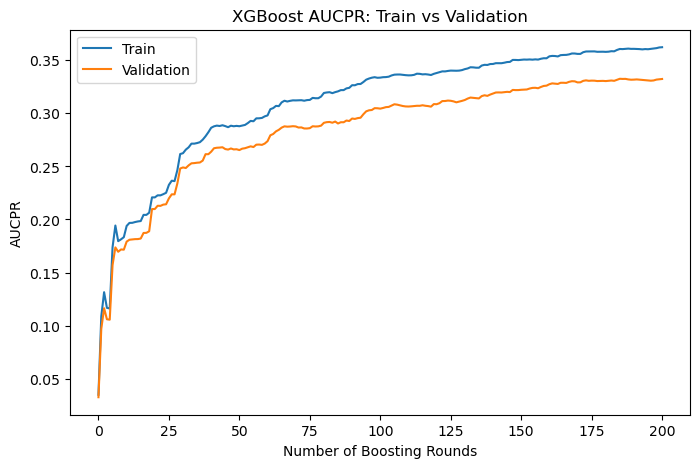

In [ ]:
#check for overtraining with train vs val aucpr

eval_set = [(train_x, train_y), (val_x, val_y)]
bestmodel.fit(train_x, train_y,
    eval_set=eval_set,
    verbose=True
)

results = bestmodel.evals_result()
epochs = len(results['validation_0']['aucpr'])
x_axis = range(0, epochs)

plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['aucpr'], label='Train')
plt.plot(x_axis, results['validation_1']['aucpr'], label='Validation')
plt.legend()
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('AUCPR')
plt.title('XGBoost AUCPR: Train vs Validation')

plt.show()


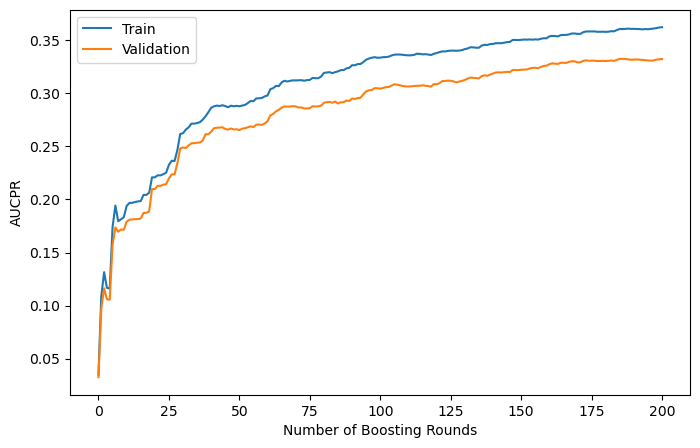

In [555]:
plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['aucpr'], label='Train')
plt.plot(x_axis, results['validation_1']['aucpr'], label='Validation')
plt.legend()
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('AUCPR')


plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\auc_pr_curve.png",dpi=300, bbox_inches="tight")

plt.show()


In [538]:
# Threshold Moving based on max significance:

pred_val = bestmodel.predict_proba(val_x)[:,1]


cuts = np.linspace(0.01, 0.99, 200)
S_array = np.array([np.sum((val_y==1) & (pred_val>=c)) for c in cuts])
B_array = np.array([np.sum((val_y==0) & (pred_val>=c)) for c in cuts])

mask = (S_array + B_array) >= 100   # s+b



fom_array = np.divide(
    S_array,
    np.sqrt(S_array + B_array),
    out=np.zeros_like(S_array, dtype=float),
    where=(S_array + B_array) > 0
)


fom_array_masked = np.where(mask, fom_array, -np.inf)
best_cut = cuts[np.argmax(fom_array_masked)]


print("Best threshold for max significance:", best_cut)

# predict on x_test with cut based on significance: 
pred = bestmodel.predict_proba(x_test)[:, 1]
preds = (pred >= best_cut).astype(int)  # threshold adjusted to significance



Best threshold for max significance: 0.9850753768844221


In [539]:
c = 0.99
print("S@0.99 =", np.sum((val_y==1) & (pred_val>c)))
print("B@0.99 =", np.sum((val_y==0) & (pred_val>c)))
print("S+B@0.99 =", np.sum(pred_val>c))


S@0.99 = 259
B@0.99 = 219
S+B@0.99 = 478


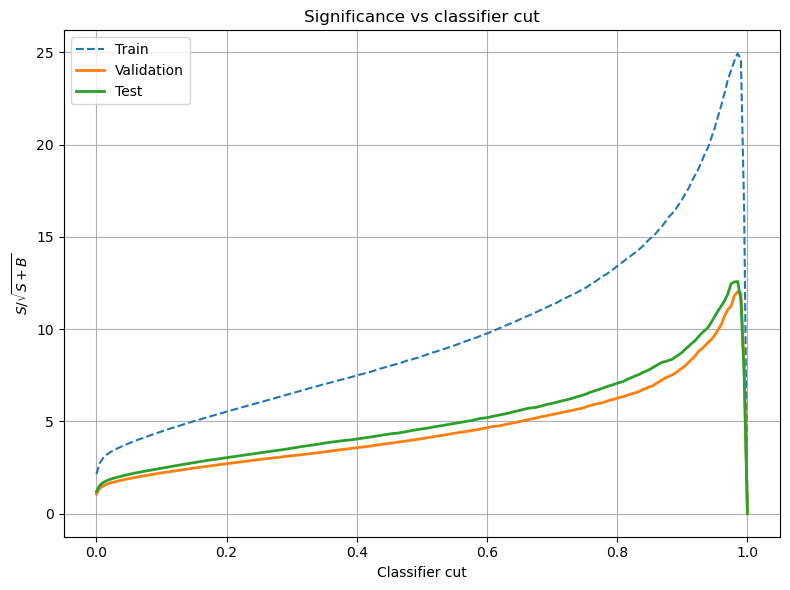

In [540]:
#this is to test for overfitting.

import numpy as np

def significance_curve(y_true, scores, n_cuts=200):
    cuts = np.linspace(0.0, 1.0, n_cuts)
    foms = []

    for c in cuts:
        S = np.sum((y_true == 1) & (scores > c))
        B = np.sum((y_true == 0) & (scores > c))

        if S + B >= 100: #threshold
            foms.append(S / np.sqrt(S + B))
        else:
            foms.append(0.0)

    return cuts, np.array(foms)




# Scores
score_train = bestmodel.predict_proba(train_x)[:, 1]
score_val   = bestmodel.predict_proba(val_x)[:, 1]
score_test  = bestmodel.predict_proba(x_test)[:, 1]

cuts_tr, fom_tr = significance_curve(train_y, score_train)
cuts_val, fom_val = significance_curve(val_y, score_val)
cuts_te, fom_te = significance_curve(y_test, score_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(cuts_tr, fom_tr, label="Train", linestyle="--")
plt.plot(cuts_val, fom_val, label="Validation", linewidth=2)
plt.plot(cuts_te, fom_te, label="Test", linewidth=2)

plt.xlabel("Classifier cut")
plt.ylabel(r"$S/\sqrt{S+B}$")
plt.title("Significance vs classifier cut")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [541]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = preds
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results


#y_proba = bestmodel.predict_proba(x_test)[:,1]
#threshold = 0.54  # experiment with 0.6, 0.65, 0.7
#y_pred_thresh = (y_proba >= threshold).astype(int)

evaluate_results(y_test, preds)

Confusion Matrix:
[[934735    699]
 [   732    422]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935434
         1.0       0.38      0.37      0.37      1154

    accuracy                           1.00    936588
   macro avg       0.69      0.68      0.69    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 37.10%
roc: 68.25%
recall: 36.57%
precision: 37.64%


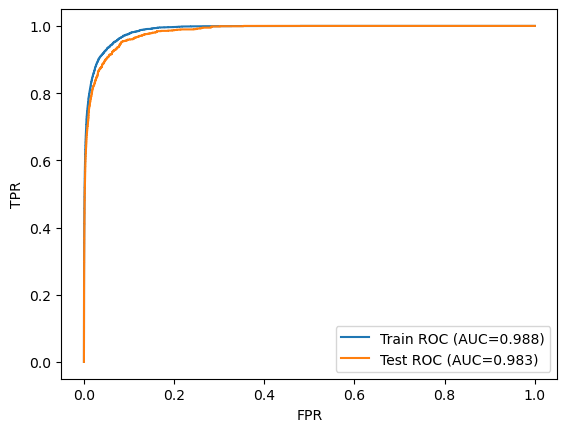

In [542]:
#checking for overfitting with roc

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = bestmodel.predict_proba(x_train_full)[:,1]
y_test_pred  = bestmodel.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train_full, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)



auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)
#plt.xscale("log")
#plt.xlim(1e-4, 1)

plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={auc_te:.3f})")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


Signal efficiency: 0.36568457538994803
Background rejection: 0.9992527532674673


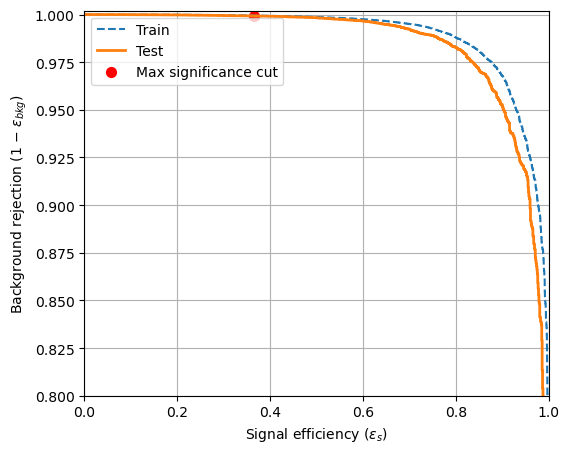

In [556]:
import matplotlib.pyplot as plt
import numpy as np

#Result on test data:

# fpr_tr, tpr_tr from ROC
# fpr_te, tpr_te

# pred_probs = model probabilities
tpr_at_cut = np.sum((preds >= best_cut) & (y_test==1)) / np.sum(y_test==1)
fpr_at_cut = np.sum((preds >= best_cut) & (y_test==0)) / np.sum(y_test==0)
bkg_rej_at_cut = 1 - fpr_at_cut

print("Signal efficiency:", tpr_at_cut)
print("Background rejection:", bkg_rej_at_cut)


fpr_te, tpr_te, thresholds_te = roc_curve(y_test, bestmodel.predict_proba(x_test)[:,1])

bkg_rej_tr = 1.0 - fpr_tr
bkg_rej_te = 1.0 - fpr_te


plt.figure(figsize=(6,5))
plt.plot(tpr_tr, bkg_rej_tr, label="Train", linestyle="--")
plt.plot( tpr_te, bkg_rej_te, label="Test", linewidth=2)
plt.scatter( tpr_at_cut, bkg_rej_at_cut, color='red', s=50, label='Max significance cut') #is the ideal cut max significance


plt.ylabel("Background rejection (1 − $ε_{bkg}$)") #Background rejection
plt.xlabel("Signal efficiency ($ε_{s}$)") #Signal efficiency
plt.ylim(0.8, 1.002)
plt.xlim(0.0, 1.001)
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\eff_vs_reject.png",dpi=300, bbox_inches="tight")

plt.show()


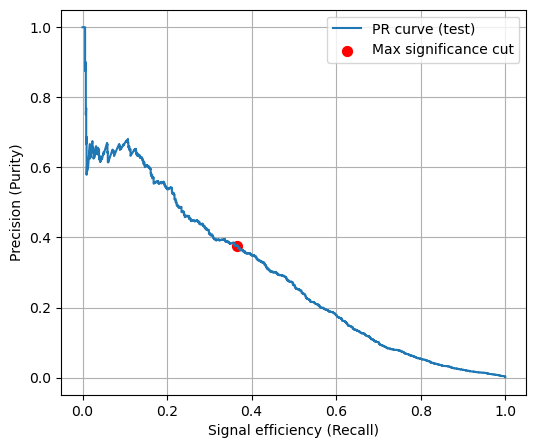

In [557]:
from sklearn.metrics import precision_recall_curve



precision, recall, thresholds = precision_recall_curve(y_test, pred)

TP = np.sum((preds == 1) & (y_test == 1))
FP = np.sum((preds == 1) & (y_test == 0))
FN = np.sum((preds == 0) & (y_test == 1))

recall_at_cut = TP / (TP + FN)        # TPR
precision_at_cut = TP / (TP + FP)     # precision


plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR curve (test)")

plt.scatter(recall_at_cut, precision_at_cut, color='red', s=50, label="Max significance cut")

plt.xlabel("Signal efficiency (Recall)")
plt.ylabel("Precision (Purity)")
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\pr_curve.png",dpi=300, bbox_inches="tight")

plt.show()


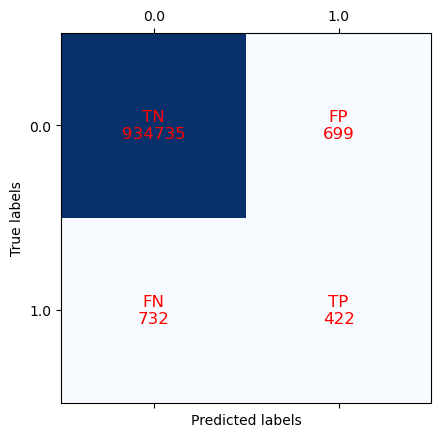

Signal efficiency/recall: 0.36568457538994803
Background rejection: 0.9992527532674673
Purity/precision: 0.37644959857270294


In [559]:

#max significance cut applied:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds)

import numpy as np

labels = np.unique(y_test)

fig, ax = plt.subplots()
im = ax.matshow(cm, cmap=plt.cm.Blues)

# 


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Voeg extra label toe
        if i==0 and j==0:
            text = f"TN\n{cm[i,j]}"
        elif i==0 and j==1:
            text = f"FP\n{cm[i,j]}"
        elif i==1 and j==0:
            text = f"FN\n{cm[i,j]}"
        else:  # i==1 and j==1
            text = f"TP\n{cm[i,j]}"
        ax.text(j, i, text, ha="center", va="center", color="red", fontsize=12)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

plt.savefig(r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\cm_xgb.png",dpi=300, bbox_inches="tight")

plt.show()

from sklearn.metrics import confusion_matrix



# purity, efficiency, background rejection
TP = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]
TN = cm[0,0]

signal_eff = TP / (TP + FN)
bkg_rej = TN / (TN + FP)
purity = TP / (TP + FP)

print("Signal efficiency/recall:", signal_eff)
print("Background rejection:", bkg_rej)
print("Purity/precision:", purity)




In [546]:

y_score = bestmodel.predict_proba(x_test)[:, 1] # is without cut

signal_scores = y_score[y_test == 1]
background_scores = y_score[y_test == 0]


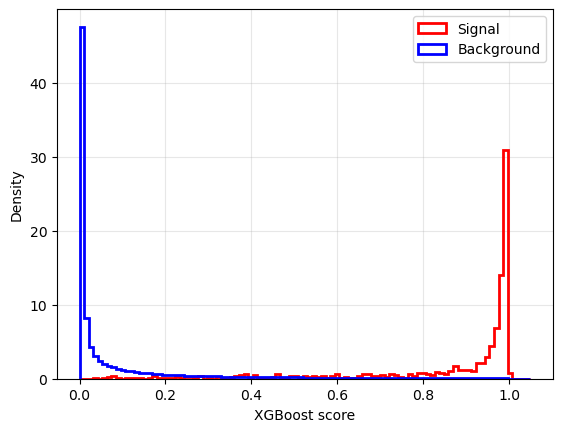

In [547]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1.05, 100)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [548]:


mask = y_score >= best_cut

mass_selected = m_test[mask]


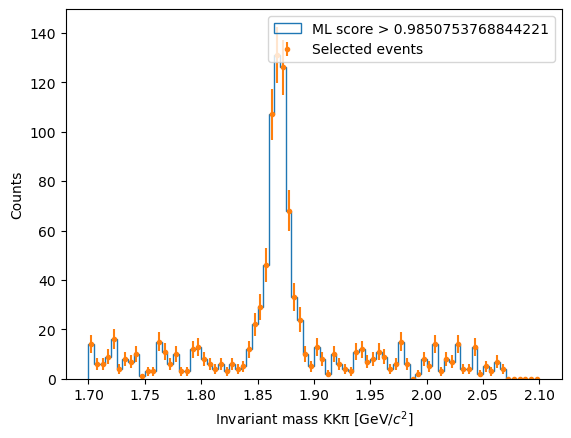

In [549]:
plt.hist(
    mass_selected,
    bins=80,
    range=(1.7, 2.1),
    histtype="step",
    label=f"ML score > {best_cut}"
)

range_mass = (1.7, 2.1)
hist_vals, bin_edges = np.histogram(mass_selected, bins=80, range=range_mass)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
errors = np.sqrt(hist_vals)  # Poisson errors

plt.errorbar(bin_centers, hist_vals, yerr=errors, fmt='.', label='Selected events')
plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.ylabel("Counts")
plt.legend()
plt.show()




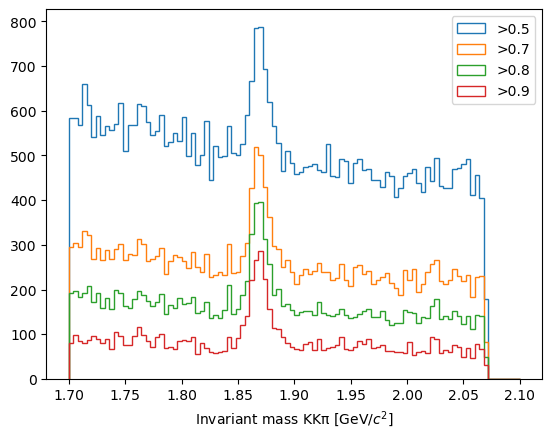

In [550]:
#check with different tresholds if peak is consistent

for cut in [0.5, 0.7, 0.8, 0.9]:
    mask = y_score > cut
    plt.hist(
        m_test[mask],
        bins=100,
        range=(1.7,2.1),
        histtype="step",
        label=f">{cut}"
    )

plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.legend()
plt.show()



In [567]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

def exponential(x, a, b, d):
    return a * np.exp(b * x) + d

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2/(2*sigma**2))

def signal_to_background_from_params(gauss_params, exp_params, k=3):
    a_g, mu_g, sigma_g = gauss_params
    a_e, b_e, d_e = exp_params

    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g
    S, _ = quad(lambda x: gaussian(x, *gauss_params), x_min, x_max)
    B, _ = quad(lambda x: exponential(x, *exp_params), x_min, x_max)
    S_over_B = S / B
    return S, B, S_over_B



# Signal uncertainty with fit, based on the the fit covariance matrix is not used, since values are negligible
from scipy.stats import norm

def S_error_from_gauss(popt_gauss, pcov_gauss, k=3):
    """
    Calculate error of signal S = integral(Gauss) ± ΔS
    based on the fit covariance matrix.
    """
    a_g, mu_g, sigma_g = popt_gauss * 1000
    cov = pcov_gauss
    

    # Bounds integration
    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g

    # derivatives from S to parameters
    # S = a * sigma * sqrt(2*pi) * erf(k/sqrt(2)) ≈ numerical
    # numerical derivatives true shift
    delta = 1e-5
    derivs = np.zeros(3)

    # a_g
    S_plus = quad(lambda x: gaussian(x, a_g+delta, mu_g, sigma_g), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g-delta, mu_g, sigma_g), x_min, x_max)[0]
    derivs[0] = (S_plus - S_minus)/(2*delta)

    # mu_g
    S_plus = quad(lambda x: gaussian(x, a_g, mu_g+delta, sigma_g), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g, mu_g-delta, sigma_g), x_min, x_max)[0]
    derivs[1] = (S_plus - S_minus)/(2*delta)

    # sigma_g
    S_plus = quad(lambda x: gaussian(x, a_g, mu_g, sigma_g+delta), x_min, x_max)[0]
    S_minus = quad(lambda x: gaussian(x, a_g, mu_g, sigma_g-delta), x_min, x_max)[0]
    derivs[2] = (S_plus - S_minus)/(2*delta)

    # Propagate errors
    S_err = np.sqrt(derivs @ cov @ derivs.T)
    return S_err


def bump_hunt(candidates, signal_window=(1.85, 1.89),savepath=None): #1.85, 1.9

    # Histogram

    #hist, bin_edges = np.histogram(candidates, bins, range=(np.min(candidates), np.max(candidates)))

    sigma_guess = 0.0092# adjust to result
    sigma_g =  sigma_guess*1000
    bin_width = sigma_guess 
    x_min, x_max = min(candidates), max(candidates)
    N_bins = int(np.ceil((x_max - x_min) / bin_width))
    hist, bin_edges = np.histogram(candidates, bins=N_bins, range=(x_min, x_max))
    

    bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


    # Exclude signal window for background fit
    mask = (bin_centers < signal_window[0]) | (bin_centers > signal_window[1])
    hist_bkg, bins_bkg = hist[mask], bin_centers[mask]

   

    # Fit exponential
    popt_exp, pcov_exp = curve_fit(exponential, bins_bkg, hist_bkg, p0=(max(hist_bkg), -1, min(hist_bkg)),maxfev=35000)

    # Fit Gaussian + exponential
    def gauss_plus_exp(x, a_g, mu_g, sigma_g):
        return gaussian(x, a_g, mu_g, sigma_g) + exponential(x, *popt_exp)
    

    
    popt_gauss, pcov_gauss = curve_fit(gauss_plus_exp, bin_centers, hist, p0=(max(hist)-min(hist), 1.869, sigma_guess),maxfev=35000)
    S, B, S_over_B = signal_to_background_from_params(popt_gauss, popt_exp)
    sigma_params = np.sqrt(np.diag(pcov_gauss))  # [Δa_g, Δmu_g, Δsigma_g]

    mu, sigma = popt_gauss[1] * 1000, popt_gauss[2] * 1000 #MeV/c2
    dmu, dsigma = sigma_params[1] *1000 , sigma_params[2] * 1000  #MeV/c2

    S_err = S_error_from_gauss(popt_gauss, pcov_gauss, k=3)


    # Plot
    x_fit = np.linspace(1.7, 2.1, 500)
    plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist), fmt='.', label='Data')
    plt.plot(x_fit, gauss_plus_exp(x_fit, *popt_gauss), label='Signal', color='green')
    plt.plot(x_fit, exponential(x_fit, *popt_exp), '--', label='Background', color='red')
   # plt.plot(x_fit, gaussian(x_fit, *popt_gauss), ':', label='Gaussian', color='blue')
    plt.text(1.91, max(hist)*0.54,
          f"μ = {mu:.3f} ± {dmu:.3f} MeV/c²\n"
          f"σ = {sigma:.3f} ± {dsigma:.3f} MeV/c²\n"
          f"S (3σ)= {S:.0f} ± {np.sqrt(S):.0f}\n",
         # f"S/B  = {S_over_B:.2f}",
        #  f"S = {S:.0f} ± {S_err:.0f}\n" #error from covariance of the Gaussian fit parameters

          bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('$M$(KKπ) (GeV/c²)')
    plt.ylabel(f"Counts per {sigma_g:.0f} MeV/c²\n")
    plt.legend()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()


    return popt_exp, popt_gauss, S, B, S_over_B





In [568]:
print("Number of events in mass_selected:", len(mass_selected))
print("Min mass:", np.min(mass_selected))
print("Max mass:", np.max(mass_selected))
print("First 10 masses:", mass_selected[:10])


Number of events in mass_selected: 478
Min mass: 1.6698929
Max mass: 2.0679896
First 10 masses: [1.8735099 1.8628697 1.7191609 1.8705236 1.8821814 1.8536779 1.6810638
 1.8768389 1.8595879 2.0435393]


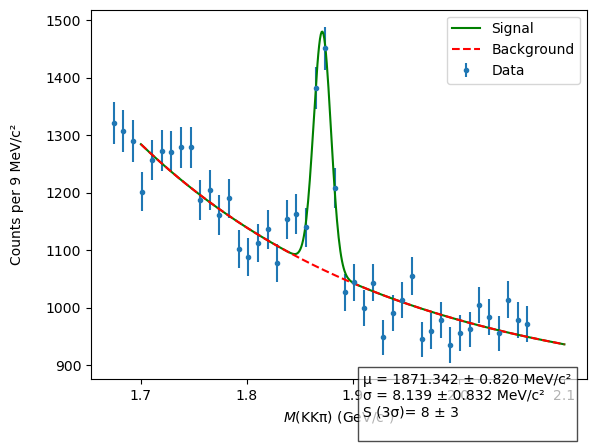

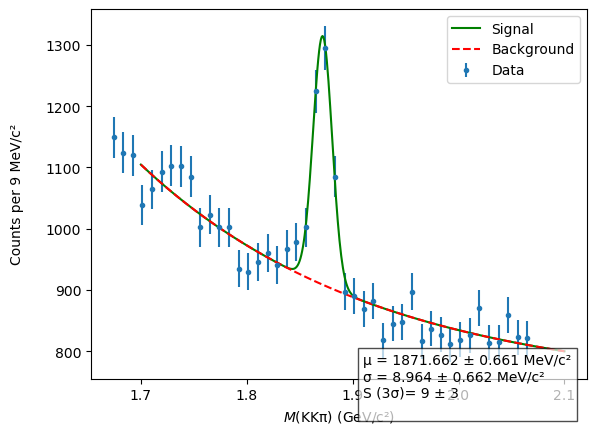

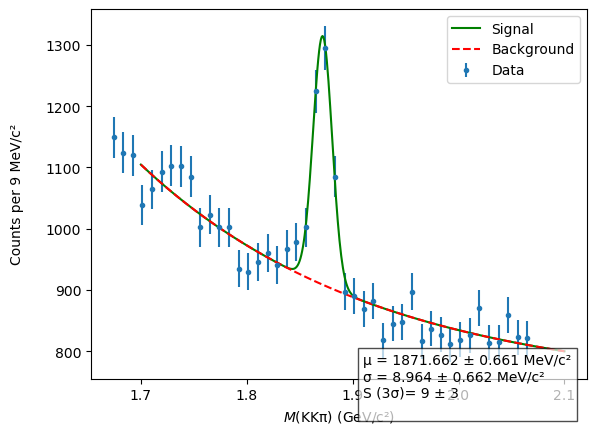

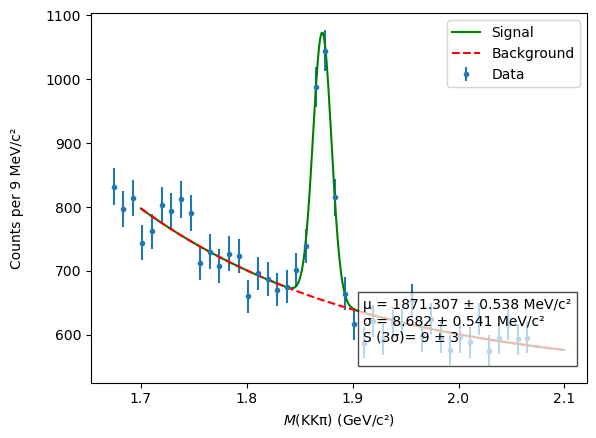

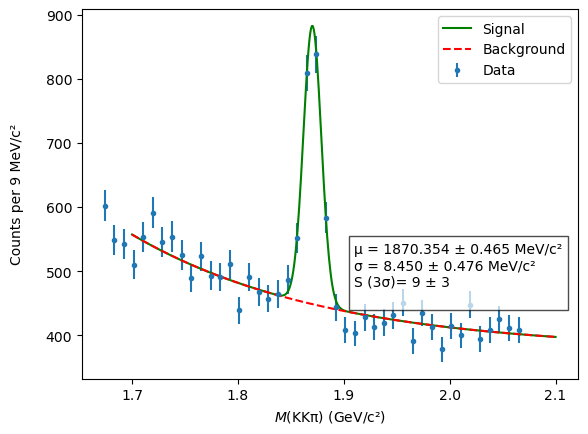

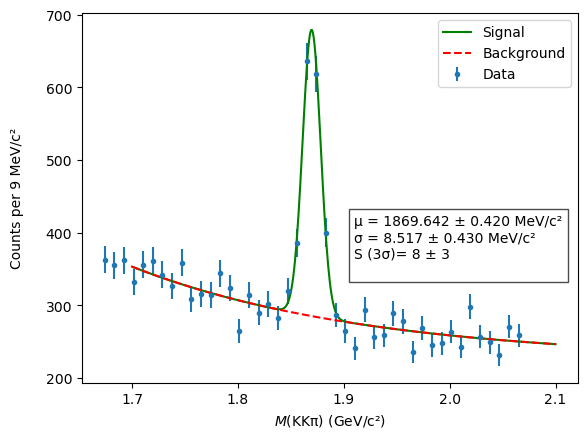

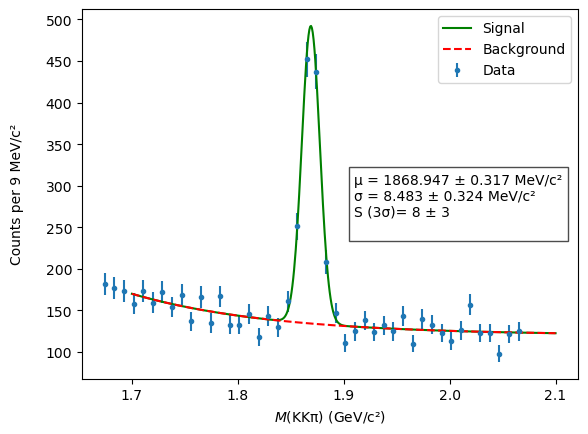

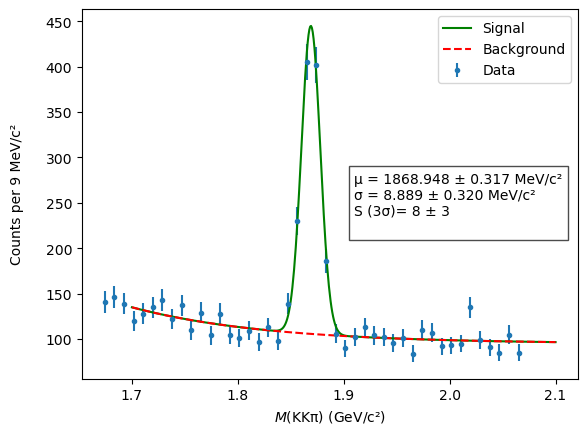

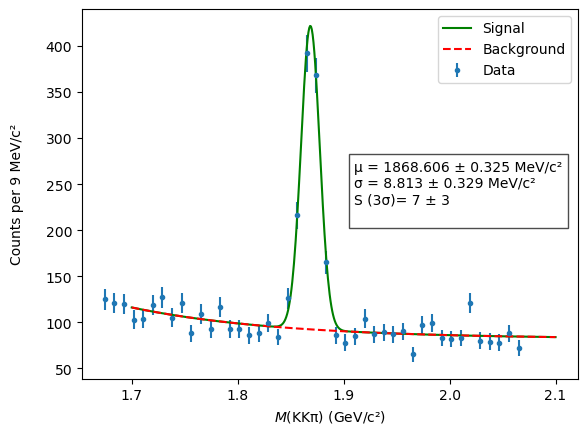

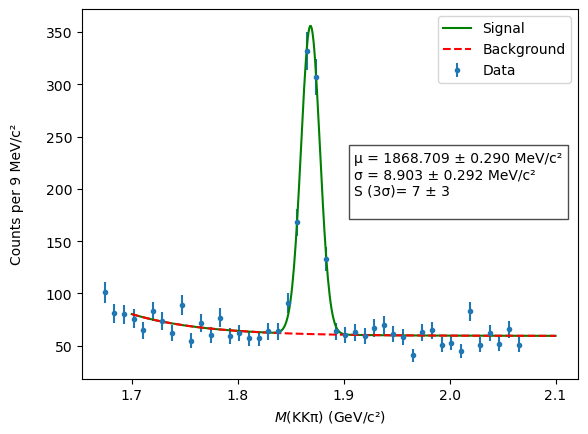

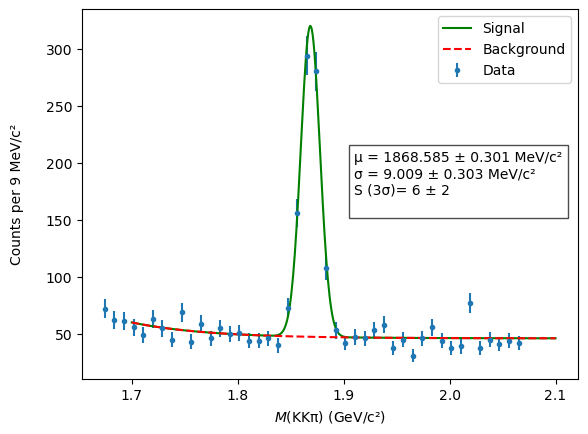

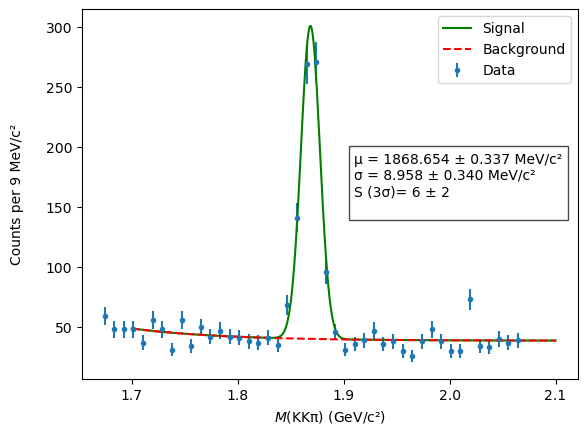

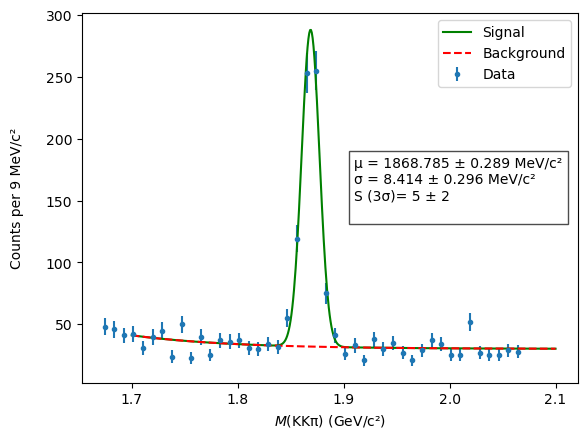

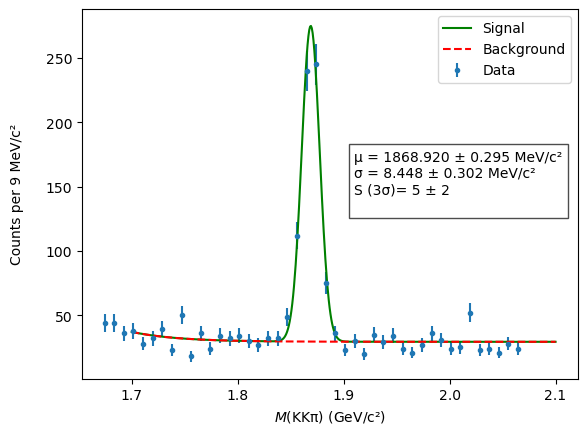

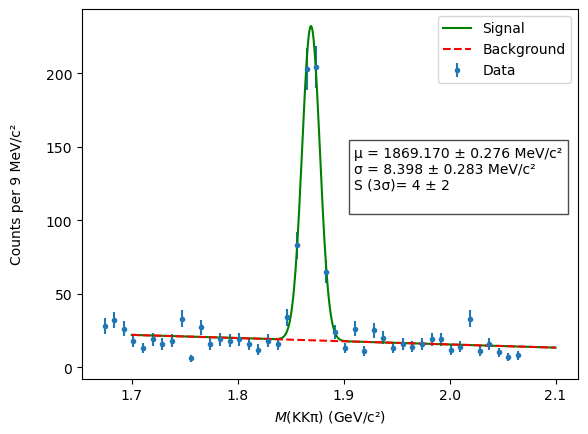

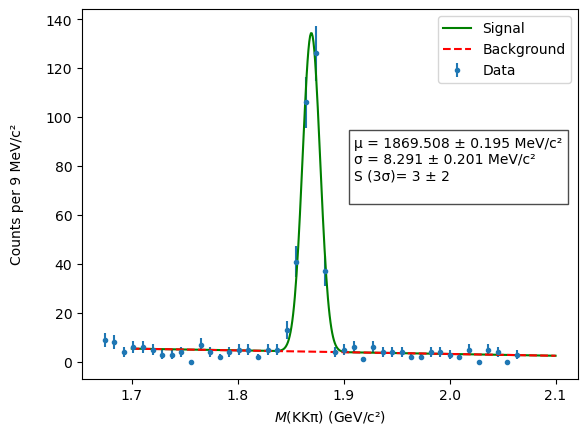

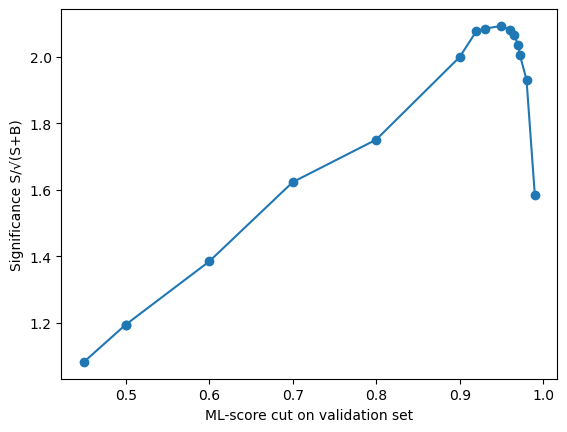

Best ML-score cut from validation set: 0.95


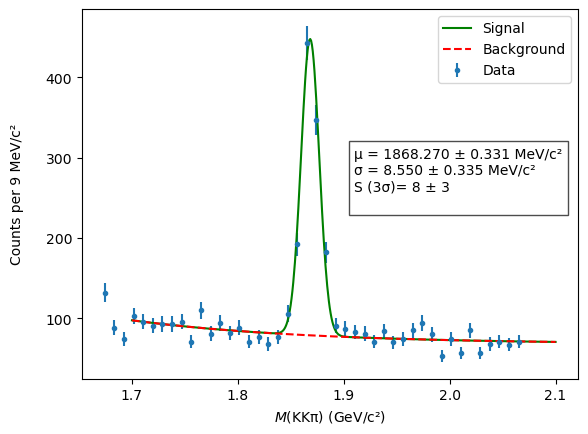

Test set significance: 2.2830629920277596
S/B: 1.949457612341412


In [569]:
#test cuts based on the validation set #58

cuts = [0.45, 0.5, 0.5, 0.6, 0.7, 0.8,0.9, 0.92,0.93, 0.95,0.96,0.965,0.97,0.972, 0.98, 0.99]
significances = []


score_val   = bestmodel.predict_proba(val_x)[:, 1]


for cut in cuts:
    mask = score_val > cut
    mass_selected = m_val[mask]
    _, _, S, B, _ = bump_hunt(mass_selected)
    sig = S / np.sqrt(S+B)
    significances.append(sig)

plt.plot(cuts, significances, marker='o')
plt.xlabel("ML-score cut on validation set")
plt.ylabel("Significance S/√(S+B)")

plt.show()


# pick best cut
best_cut = cuts[np.argmax(significances)]
print("Best ML-score cut from validation set:", best_cut)

# apply cut to test set for final result:
score_test = bestmodel.predict_proba(x_test)[:, 1]
mask_test = score_test > best_cut
mass_selected_test = m_test[mask_test]

popt_exp, popt_gauss, S, B, S_over_B = bump_hunt(mass_selected_test, signal_window=(1.84, 1.89),savepath=r"C:\Users\apogo\Documents\Studie Master\Machine Learning\PLots\signal_xgb.png")
significance = S / np.sqrt(S + B)
print("Test set significance:", significance)
print("S/B:", S_over_B)


